In [42]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer, util

In [43]:
with open("code_corpus.json", "r", encoding="utf-8") as f:
    code_corpus = json.load(f)

with open("eval_questions.json", "r", encoding="utf-8") as f:
    eval_questions = json.load(f)

with open("categories.json", "r", encoding="utf-8") as f:
    categories_data = json.load(f)

print(f"количество функций: {len(code_corpus)}")
print(f"количество вопросов: {len(eval_questions)}")
print(f"количество категорий: {len(categories_data['categories'])}")

количество функций: 200
количество вопросов: 25
количество категорий: 5


In [44]:
model_mpnet = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")
model_labse = SentenceTransformer("LaBSE")
print("модели загружены")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

модели загружены


In [45]:
corpus_texts = []
corpus_ids = []
corpus_categories = []

for item in code_corpus:
    corpus_texts.append(f"{item['function_name']}: {item['description']}")
    corpus_ids.append(item['id'])
    corpus_categories.append(item['category'])

print(f"подготовлено {len(corpus_texts)} текстов")

подготовлено 200 текстов


In [46]:
embeddings_mpnet = model_mpnet.encode(corpus_texts, show_progress_bar=True)
np.save("embeddings_mpnet.npy", embeddings_mpnet)
print("MPNet готово")

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

MPNet готово


In [47]:
embeddings_labse = model_labse.encode(corpus_texts, show_progress_bar=True)
np.save("embeddings_labse.npy", embeddings_labse)
print("LaBSE готово")

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

LaBSE готово


In [48]:
def search(query, model, embeddings):
    q_emb = model.encode(query)
    scores = np.dot(embeddings, q_emb) / (np.linalg.norm(embeddings, axis=1) * np.linalg.norm(q_emb))
    top_idx = np.argsort(scores)[-3:][::-1]
    results = []
    for idx in top_idx:
        results.append({
            'id': corpus_ids[idx],
            'score': float(scores[idx])
        })
    return results

In [49]:
def precision_at_3(model, embeddings):
    correct = 0
    for q in eval_questions:
        top = search(q["query"], model, embeddings)
        top_ids = [r["id"] for r in top]
        if q["correct_chunk_id"] in top_ids:
            correct += 1
    return correct / len(eval_questions)

p_mpnet = precision_at_3(model_mpnet, embeddings_mpnet)
p_labse = precision_at_3(model_labse, embeddings_labse)

print(f"MPNet Precision@3: {p_mpnet:.3f}")
print(f"LaBSE Precision@3: {p_labse:.3f}")

MPNet Precision@3: 0.920
LaBSE Precision@3: 0.960


In [50]:
df = pd.DataFrame([
    ["paraphrase-multilingual-mpnet-base-v2", p_mpnet],
    ["LaBSE", p_labse]
], columns=["модель", "Precision@3"])
df = df.sort_values("Precision@3", ascending=False)
print(df.to_string(index=False))
df.to_csv("model_comparison.csv", index=False)

                               модель  Precision@3
                                LaBSE         0.96
paraphrase-multilingual-mpnet-base-v2         0.92


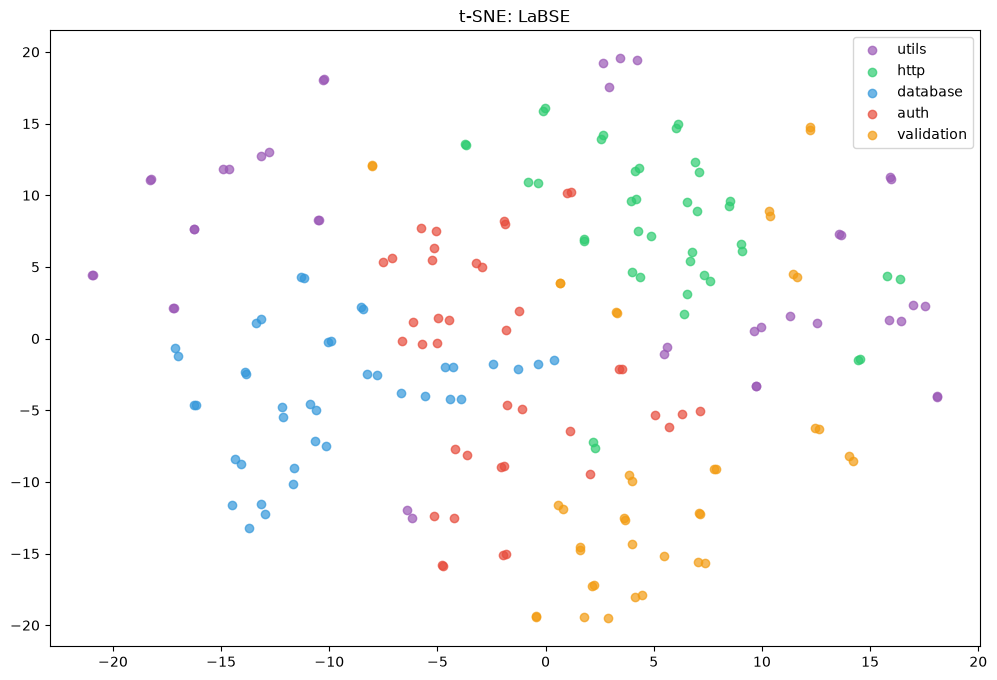

In [51]:
best_emb = embeddings_mpnet if p_mpnet > p_labse else embeddings_labse
best_name = "MPNet" if p_mpnet > p_labse else "LaBSE"

tsne = TSNE(n_components=2, random_state=42)
coords = tsne.fit_transform(best_emb)

colors = {cat["key"]: cat["color"] for cat in categories_data["categories"]}

plt.figure(figsize=(12, 8))
for cat in set(corpus_categories):
    mask = [c == cat for c in corpus_categories]
    plt.scatter(
        coords[mask, 0],
        coords[mask, 1],
        label=cat,
        color=colors[cat],
        alpha=0.7
    )

plt.legend()
plt.title(f"t-SNE: {best_name}")
plt.savefig("tsne_plot.png", dpi=300)
plt.show()

In [58]:
errors = {}
total = {}
for q in eval_questions:
    cat = next(item["category"] for item in code_corpus if item["id"] == q["correct_chunk_id"])
    total[cat] = total.get(cat, 0) + 1
    top = search(q["query"], model_labse, embeddings_labse)
    if q["correct_chunk_id"] not in [r["id"] for r in top]:
        errors[cat] = errors.get(cat, 0) + 1

df_err = pd.DataFrame([{"категория": k, "ошибок": errors.get(k,0), "всего": total[k]} for k in total])
df_err["точность"] = round((df_err["всего"] - df_err["ошибок"]) / df_err["всего"] * 100, 1)
print("модель: LaBSE")
print(df_err.to_string(index=False))
df_err.to_csv("error_analysis.csv", index=False)

модель: LaBSE
 категория  ошибок  всего  точность
      auth       1      5      80.0
  database       0      5     100.0
      http       0      5     100.0
validation       0      5     100.0
     utils       0      5     100.0


In [61]:
ru = [q for q in eval_questions if q["language"] == "ru"]
en = [q for q in eval_questions if q["language"] == "en"]

def p3(qs):
    if not qs: return 0
    return sum(1 for q in qs if q["correct_chunk_id"] in [r["id"] for r in search(q["query"], model_labse, embeddings_labse)]) / len(qs)

lang_df = pd.DataFrame([
    ["Русский", len(ru), round(p3(ru), 3)],
    ["Английский", len(en), round(p3(en), 3)]
], columns=["Язык", "Вопросов", "Precision@3"])
print("Модель: LaBSE")
print(lang_df.to_string(index=False))
lang_df.to_csv("language_comparison.csv", index=False)

Модель: LaBSE
      Язык  Вопросов  Precision@3
   Русский        15        0.933
Английский        10        1.000


In [60]:
model3 = SentenceTransformer("all-MiniLM-L6-v2")
emb3 = model3.encode(corpus_texts, show_progress_bar=True)

correct = 0
for q in eval_questions:
    top = search(q["query"], model3, emb3)
    if q["correct_chunk_id"] in [r["id"] for r in top]:
        correct += 1

df3 = pd.DataFrame([
    ["LaBSE", round(p_labse, 3)],
    ["MPNet", round(p_mpnet, 3)],
    ["all-MiniLM-L6-v2", round(correct/len(eval_questions), 3)]
], columns=["модель", "Precision@3"]).sort_values("Precision@3", ascending=False)
print(df3.to_string(index=False))
df3.to_csv("three_models.csv", index=False)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

          модель  Precision@3
           LaBSE         0.96
           MPNet         0.92
all-MiniLM-L6-v2         0.52
